In [25]:
# Importa as bibliotecas necessárias
import json

# pandas para manipulação de dados
import pandas as pd
import matplotlib.pyplot as plt

# Glob para ler os arquivos JSON
import glob

# converter o json para duckdb
import duckdb

In [26]:
conn.close()

#datosvideos = conn.execute("SELECT SUM(like_count), SUM(comments_count) FROM medias WHERE media_type = 'IMAGE' ORDER BY like_count DESC")
#datosimagen = conn.execute("SELECT SUM(like_count), SUM(comments_count) FROM medias WHERE media_type = 'VIDEO' ORDER BY like_count DESC")
#datoscarousel = conn.execute("SELECT SUM(like_count), SUM(comments_count) FROM medias WHERE media_type = 'CAROUSEL_ALBUM' " + lista_media_type[2] +"ORDER BY like_count DESC")


In [32]:

lista_media_type = ["IMAGE", "VIDEO", "CAROUSEL_ALBUM"]

conn = duckdb.connect(database='./duckdb/instagram.duckdb', read_only=False)
datosvideos = conn.execute("SELECT SUM(like_count) as like, SUM(comments_count) as comments FROM medias WHERE media_type = 'IMAGE'").fetchdf()
datosimagen = conn.execute("SELECT SUM(like_count) as like, SUM(comments_count) as comments FROM medias WHERE media_type = 'VIDEO'").fetchdf()
datoscarousel = conn.execute("SELECT SUM(like_count) as like, SUM(comments_count) as comments FROM medias WHERE media_type = 'CAROUSEL_ALBUM' ").fetchdf()
# desconectar do banco de dados
conn.close()

In [ ]:
# 1. Crear datos de ejemplo

x = ['Likes', "Coments"]
data = {
    'Like a Imagen': datosimagen,
    'Like a Videos': datosvideos,
    'Like a Carousel': datoscarousel
}
display(data)
df = pd.DataFrame(data, x)
display(df)

KeyError: 0

In [ ]:
# 2. Visualizar gráfico de líneas
df.plot(
    kind='line',
    marker='0',
    ylabel = 'Cantidades'
)

plt.title('Cantidades de Like a Imagen, Videos e Carousel')
plt.ylabel('Cantidades')
plt.grid(True)
plt.show()


TypeError: no numeric data to plot

TypeError: no numeric data to plot

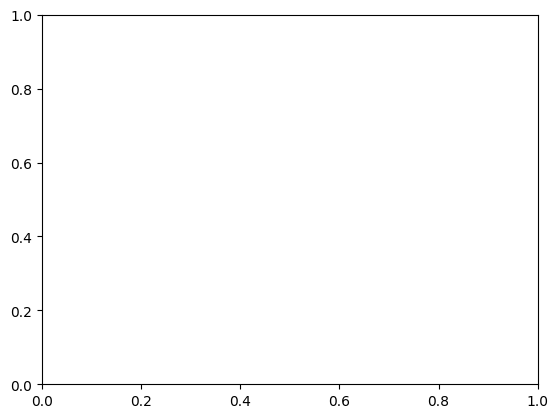

In [ ]:
# 3. Visualizar gráfico de barras
df.plot(
    kind='bar',
    grid = True,
    ylabel = 'Cantidades',
    color='skyblue'
)

#4. Visualizar gráficos de áreas
df.plot(
    kind = 'area',
    ylabel = 'Cantidades',
    stacked = False,
    alpha = 0.7
)


plt.title('Comparación de las cantidades de Like por tipo de publicación')
plt.show()